In [1]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import scipy.sparse as sp


## Data loading

### TR1 and L2

In [4]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Implementation/TR1%20and%20L2/L2_TR.csv")

df = df.drop(columns=["Unnamed: 0","sentlength","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

# Count of L1 per L2
count_per_L2 = df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)

# define mapping
l1_map = {
    "de": 0,
    "es": 1,
    "fr": 2,
    "it": 3
}

# apply mapping
df["L1_num"] = df["L1"].map(l1_map)

# define mapping
dataset_map = {
    "L2": 0,
    "TR": 1,
}

# apply mapping
df["dataset_name_map"] = df["dataset_name"].map(dataset_map)

# Data balancing across entire data set
L2 = df[df['dataset_name'] == 'L2']
TR1 = df[df['dataset_name'] == 'TR']


""" concating lets do it afterwards!
df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)"""




Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167


' concating lets do it afterwards!\ndf_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)'

### Europarl (TR2)

In [5]:
# Europarl data

TR2 = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Data%20Generation/Datasets/europarl/europarl_all_data.csv")

TR2 = TR2.drop(columns="sentlength",axis = "columns")
TR2 = TR2.drop(columns=["Unnamed: 0","alang","akorp","afile","astatus"],axis = "columns")


TR2["L1_num"] = TR2["L1"].map(l1_map)
num_cols = TR2.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp', 'L1_num']


# RQ1: Running Experiments (K-means and NN) individually in TR1, TR2 and L2
(For each data downsample to their minimum value)

- Note: In previous experiments there were warnings regarding ill defined  labels with no predicted samples (which led to confusion matrix omittig such cases)  
- Also I've scaled the features -  it didn't change results that much but now its consistant

## Kmeans

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_kmeans_evaluation(df, n_clusters=None, label_col='L1', drop_cols=None, plot=True):

    df = df.dropna().copy()

    # Separate labels
    y_true = df[label_col].values

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.drop(columns=[label_col])

    X = df_features.values

    # SCALE FEATURES
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Auto-set clusters = number of classes if not given
    if n_clusters is None:
        n_clusters = len(np.unique(y_true))

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(X)

    df['cluster'] = cluster_ids

    cluster_to_label = {}

    for cluster in np.unique(cluster_ids):
        mask = (cluster_ids == cluster)

        if np.sum(mask) == 0:
            continue

        unique_labels, counts = np.unique(y_true[mask], return_counts=True)

        # Assign most frequent label
        cluster_to_label[cluster] = unique_labels[np.argmax(counts)]

    # Map predictions
    y_pred = np.array([cluster_to_label[c] for c in cluster_ids])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("Clustering Accuracy:", accuracy)
    labels = sorted(set(y_true) | set(y_pred))

    confusion_matrix = pd.crosstab(
        y_true,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)
    print(confusion_matrix)

    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, digits=4, zero_division=0))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

### L2

L1
es    1100
de    1100
it    1100
fr    1100
Name: count, dtype: int64
Clustering Accuracy: 0.32295454545454544
Pred   de   es  fr  it
True                  
de    881  219   0   0
es    560  540   0   0
fr    779  321   0   0
it    615  485   0   0

Classification Report:
               precision    recall  f1-score   support

          de     0.3108    0.8009    0.4478      1100
          es     0.3450    0.4909    0.4053      1100
          fr     0.0000    0.0000    0.0000      1100
          it     0.0000    0.0000    0.0000      1100

    accuracy                         0.3230      4400
   macro avg     0.1640    0.3230    0.2133      4400
weighted avg     0.1640    0.3230    0.2133      4400



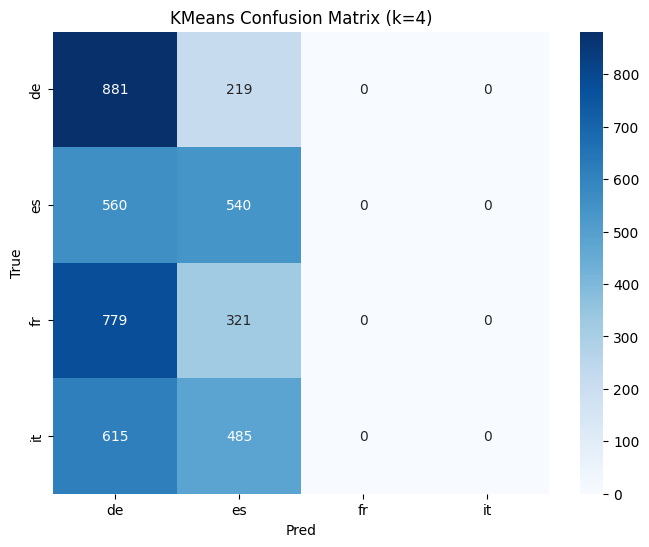

In [7]:
print(L2["L1"].value_counts())

min_count = L2["L1"].value_counts().min()

# Downsample each class to that size
L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)

L2_df, acc, cm = run_kmeans_evaluation(L2, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"], plot=True)

### TR1

L1
fr    89626
de    27743
es    18604
it     2167
Name: count, dtype: int64
Clustering Accuracy: 0.3573907009021513
Pred   de   es   fr   it
True                    
de    975  232  565  381
es    836  770  560    1
fr    898  452  816    1
it    325  631  674  529

Classification Report:
               precision    recall  f1-score   support

          de     0.3214    0.4529    0.3759      2153
          es     0.3693    0.3553    0.3622      2167
          fr     0.3120    0.3766    0.3413      2167
          it     0.5800    0.2450    0.3445      2159

    accuracy                         0.3574      8646
   macro avg     0.3957    0.3574    0.3560      8646
weighted avg     0.3956    0.3574    0.3560      8646



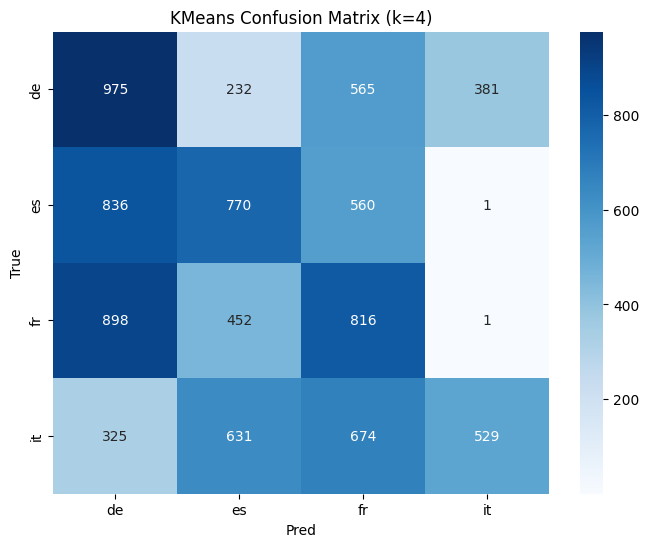

In [8]:
print(TR1["L1"].value_counts())

min_count = TR1["L1"].value_counts().min()

# Downsample each class to that size
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)


TR1_df, acc, cm = run_kmeans_evaluation(TR1, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"], plot=True)


#### TR2

L1
de    479
fr    476
it    463
es    272
Name: count, dtype: int64
Clustering Accuracy: 0.5257352941176471
Pred   de   es   fr   it
True                    
de    187   55   25    5
es     52  102   67   51
fr     77   30  157    8
it     17   74   55  126

Classification Report:
               precision    recall  f1-score   support

          de     0.5616    0.6875    0.6182       272
          es     0.3908    0.3750    0.3827       272
          fr     0.5164    0.5772    0.5451       272
          it     0.6632    0.4632    0.5455       272

    accuracy                         0.5257      1088
   macro avg     0.5330    0.5257    0.5229      1088
weighted avg     0.5330    0.5257    0.5229      1088



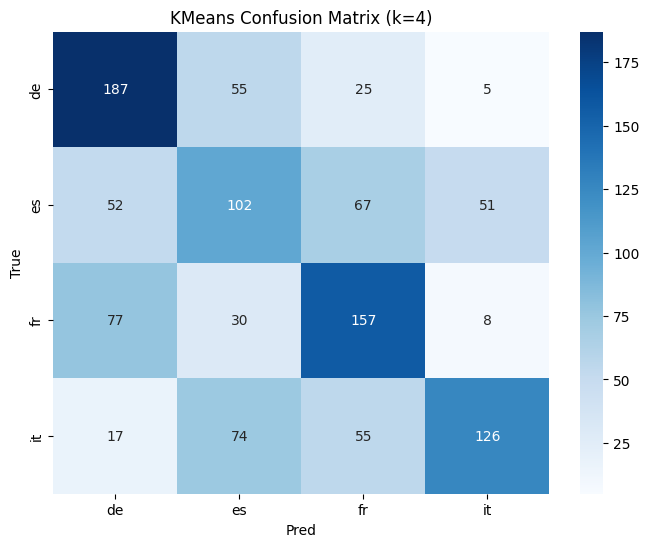

In [9]:
print(TR2["L1"].value_counts())

min_count = TR2["L1"].value_counts().min()

# Downsample each class to that size
TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)


TR2_df, acc, cm = run_kmeans_evaluation(TR2, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num'], plot=True)


## NN

In [10]:
import scipy.sparse as sp
from sklearn.metrics import confusion_matrix



def run_nn(df, features, label_col="L1", title="Neural Network"):


    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )



    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Ensure X is dense float64

    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train_s = to_dense_float(X_train_s)
    X_test_s  = to_dense_float(X_test_s)


    # Ensure y is a plain 1D array (not sparse, not weird dtype)
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)


    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)

    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm


### L2


===== MLP Classification of L2 dataset(Test set) =====
Test Accuracy: 0.48295454545454547

Classification Report:
               precision    recall  f1-score   support

          de     0.4801    0.6045    0.5352       220
          es     0.4749    0.4727    0.4738       220
          fr     0.4673    0.4227    0.4439       220
          it     0.5135    0.4318    0.4691       220

    accuracy                         0.4830       880
   macro avg     0.4840    0.4830    0.4805       880
weighted avg     0.4840    0.4830    0.4805       880


Confusion matrix:
[[133  30  35  22]
 [ 41 104  40  35]
 [ 59  35  93  33]
 [ 44  50  31  95]]


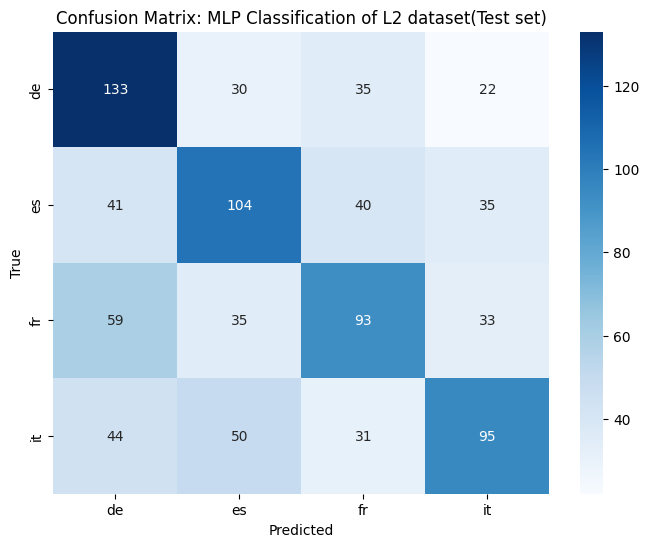

In [11]:
features = L2.drop(columns=['L1','L1_num',"dataset_name_map","dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(L2, features, label_col="L1", title="MLP Classification of L2 dataset(Test set)")

### TR1


===== MLP Classification of TR1 dataset(Test set) =====
Test Accuracy: 0.6092485549132948

Classification Report:
               precision    recall  f1-score   support

          de     0.5854    0.4292    0.4953       431
          es     0.5812    0.6843    0.6286       434
          fr     0.6859    0.6305    0.6570       433
          it     0.5921    0.6921    0.6382       432

    accuracy                         0.6092      1730
   macro avg     0.6112    0.6090    0.6048      1730
weighted avg     0.6112    0.6092    0.6049      1730


Confusion matrix:
[[185  74  41 131]
 [ 37 297  60  40]
 [ 41  84 273  35]
 [ 53  56  24 299]]


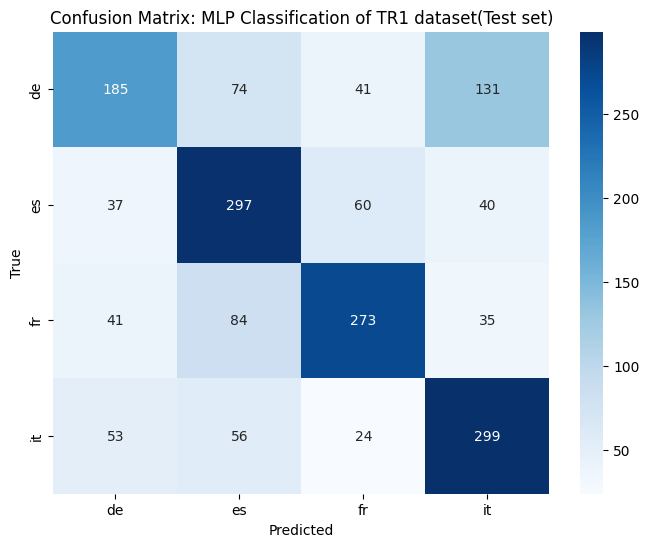

In [12]:
features = TR1.drop(columns=['L1','L1_num',"dataset_name_map","dataset_name"]).select_dtypes(include=[np.number]).columns
TR1 = TR1.dropna()
mlp_model, acc, cm = run_nn(TR1, features, label_col="L1", title="MLP Classification of TR1 dataset(Test set)")


===== MLP Classification of TR2 dataset(Test set) =====
Test Accuracy: 0.7614678899082569

Classification Report:
               precision    recall  f1-score   support

          de     0.8226    0.9273    0.8718        55
          es     0.6275    0.5926    0.6095        54
          fr     0.8235    0.7636    0.7925        55
          it     0.7593    0.7593    0.7593        54

    accuracy                         0.7615       218
   macro avg     0.7582    0.7607    0.7583       218
weighted avg     0.7588    0.7615    0.7589       218


Confusion matrix:
[[51  1  3  0]
 [ 5 32  6 11]
 [ 3  8 42  2]
 [ 3 10  0 41]]


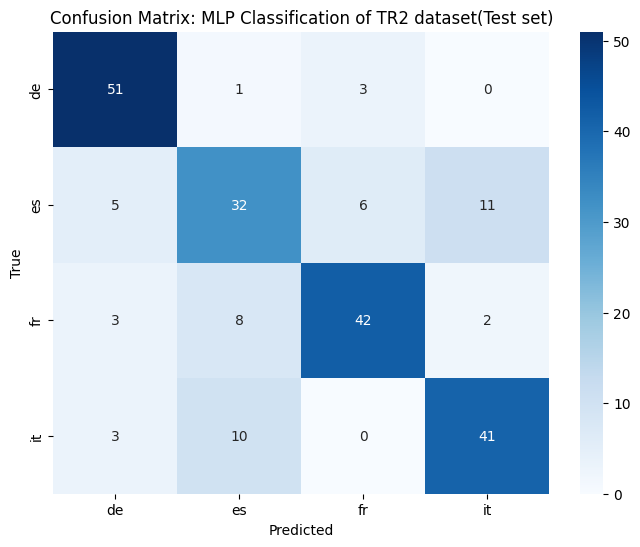

In [13]:
features = TR2.drop(columns=['L1','L1_num']).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR2, features, label_col="L1", title="MLP Classification of TR2 dataset(Test set)")

# Combining all 3 TR1, TR2, L2 then doing KMeans and NN (downsampling individually)

In [14]:
df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Clustering Accuracy: 0.3019316265521999
Pred  de    es    fr    it
True                      
de     0  1038   755  1460
es     0  1070  1102  1095
fr     0   967  1207  1093
it     0   529  1068  1662

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000      3253
          es     0.2969    0.3275    0.3115      3267
          fr     0.2921    0.3695    0.3263      3267
          it     0.3130    0.5100    0.3879      3259

    accuracy                         0.3019     13046
   macro avg     0.2255    0.3017    0.2564     13046
weighted avg     0.2257    0.3019    0.2566     13046



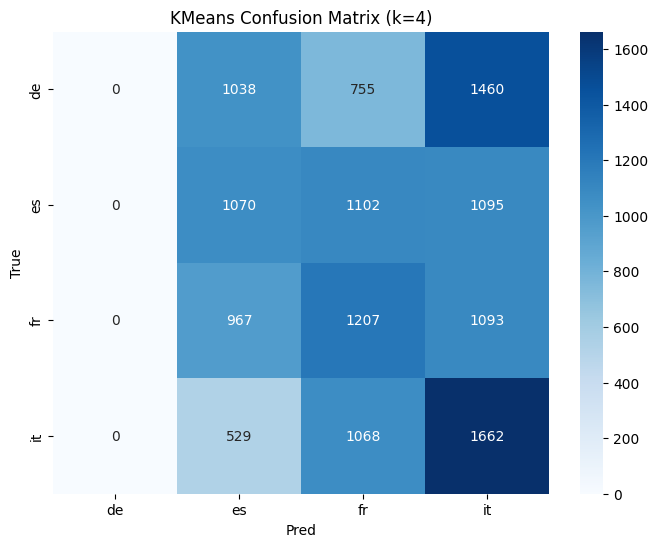

In [15]:
df, acc, cm = run_kmeans_evaluation(df, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"], plot=True)


===== MLP Classification of all dataset(Test set) =====
Test Accuracy: 0.5720306513409962

Classification Report:
               precision    recall  f1-score   support

          de     0.5574    0.4700    0.5100       651
          es     0.5491    0.5902    0.5689       654
          fr     0.5886    0.5850    0.5868       653
          it     0.5910    0.6426    0.6157       652

    accuracy                         0.5720      2610
   macro avg     0.5715    0.5720    0.5704      2610
weighted avg     0.5715    0.5720    0.5704      2610


Confusion matrix:
[[306 106 100 139]
 [ 78 386  93  97]
 [106 111 382  54]
 [ 59 100  74 419]]


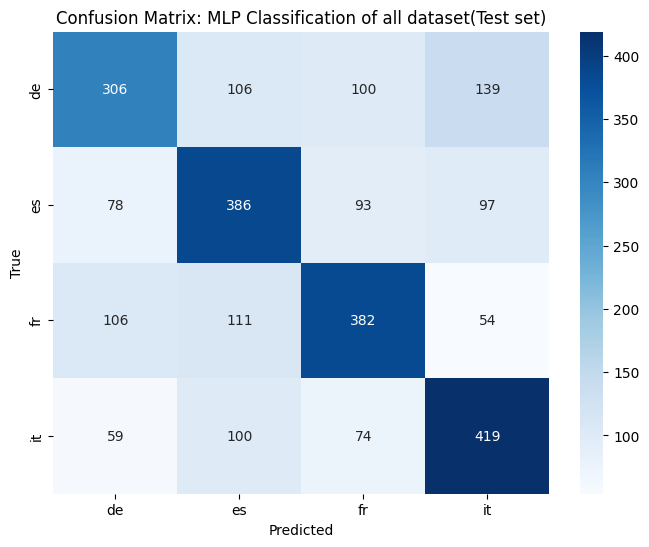

In [16]:
features = df.drop(columns=['L1','L1_num',"dataset_name_map","dataset_name"]).select_dtypes(include=[np.number]).columns
df = df.dropna()
mlp_model, acc, cm = run_nn(df, features, label_col="L1", title="MLP Classification of all dataset(Test set)")

# RQ3: Train on one and test on others - NN
- (L2 -> TR1, TR2)
- (TR1 -> L2, TR2)
- (TR2 -> TR1, L2)

In [17]:
exclude_cols = ["L1", "dataset_name", "L1_num", "dataset_name_map"]

features = [col for col in L2.columns if col not in exclude_cols]

In [18]:
def train_one_test_two(
    train_df,
    test_df,
    features,
    label_col="L1",
    title="Cross Dataset NN",
    plot=True
):

    # -----------------------
    # 1. Split features/labels
    # -----------------------
    X_train = train_df[features].values
    y_train = train_df[label_col].values

    X_test = test_df[features].values
    y_test = test_df[label_col].values

    # -----------------------
    # 2. Label Encoding (fit ONLY on train)
    # -----------------------
    if y_train.dtype.kind in {'O', 'U', 'S'}:
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)
    else:
        le = None

    # -----------------------
    # 3. Handle NaNs (IMPORTANT)
    # -----------------------
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # -----------------------
    # 4. Scaling (fit ONLY on train)
    # -----------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # -----------------------
    # 5. Ensure dense float
    # -----------------------
    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train = to_dense_float(X_train)
    X_test  = to_dense_float(X_test)

    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)

    # -----------------------
    # 6. Model
    # -----------------------
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )


    mlp.fit(X_train, y_train)

    # -----------------------
    # 7. Prediction
    # -----------------------
    y_pred = mlp.predict(X_test)

    # -----------------------
    # 8. Metrics
    # -----------------------
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    print("\nClassification Report:\n",
          classification_report(y_test, y_pred, digits=4, zero_division=0))

    # -----------------------
    # 9. Confusion Matrix (clean + aligned)
    # -----------------------
    labels = sorted(set(y_test) | set(y_pred))

    cm_df = pd.crosstab(
        y_test,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)

    # Optional: map labels to readable names
    if le is not None:
        class_names = le.inverse_transform(labels)
        cm_df.index = class_names
        cm_df.columns = class_names

    print("\nConfusion Matrix:\n", cm_df)

    # -----------------------
    # 10. Plot
    # -----------------------
    if plot:
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_df,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=cm_df.columns,
            yticklabels=cm_df.index
        )
        plt.title(f"Confusion Matrix: {title}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    return mlp, accuracy, cm_df

In [19]:
df_L2_TR2 = pd.concat([L2, TR2], axis=0).reset_index(drop=True)
df_TR1_TR2 = pd.concat([TR1, TR2], axis=0).reset_index(drop=True)
df_TR1_L2 = pd.concat([TR1, L2], axis=0).reset_index(drop=True)

TR1 = TR1.dropna()
L2 = L2.dropna()
TR2 = TR2.dropna()


===== TR1 -> (L2 + TR2) =====
Test Accuracy: 0.33983236151603496

Classification Report:
               precision    recall  f1-score   support

           0     0.3798    0.5736    0.4570      1372
           1     0.2981    0.3171    0.3073      1372
           2     0.3061    0.1203    0.1727      1372
           3     0.3371    0.3484    0.3427      1372

    accuracy                         0.3398      5488
   macro avg     0.3303    0.3398    0.3199      5488
weighted avg     0.3303    0.3398    0.3199      5488


Confusion Matrix:
      de   es   fr   it
de  787  240   92  253
es  379  435  128  430
fr  586  364  165  257
it  320  420  154  478


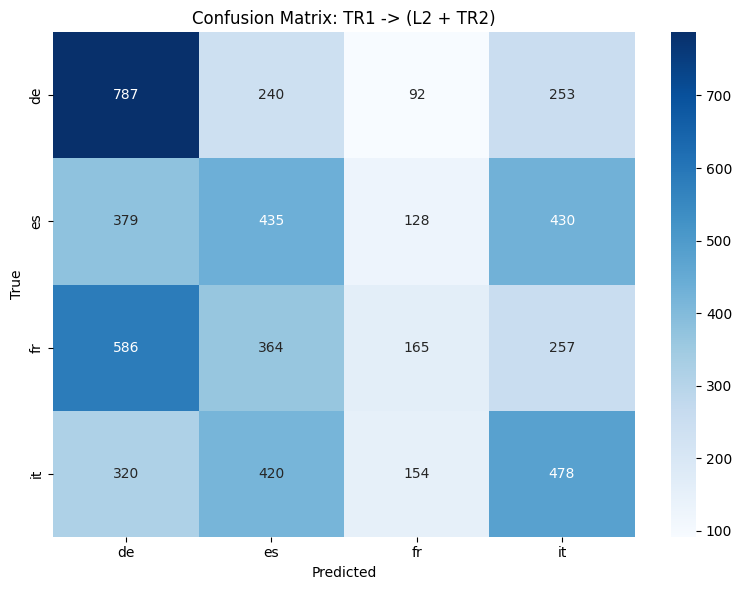

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.33983236151603496,
      de   es   fr   it
 de  787  240   92  253
 es  379  435  128  430
 fr  586  364  165  257
 it  320  420  154  478)

In [20]:
train_one_test_two(
    TR1,
    df_L2_TR2,
    features,
    title="TR1 -> (L2 + TR2)"
)


===== L2 -> (TR1 + TR2) =====
Test Accuracy: 0.2523114855146908

Classification Report:
               precision    recall  f1-score   support

           0     0.3917    0.2214    0.2829      2425
           1     0.1732    0.1566    0.1645      2439
           2     0.3344    0.1710    0.2263      2439
           3     0.2281    0.4607    0.3051      2431

    accuracy                         0.2523      9734
   macro avg     0.2818    0.2524    0.2447      9734
weighted avg     0.2817    0.2523    0.2446      9734


Confusion Matrix:
      de   es   fr    it
de  537  587  471   830
es  338  382  163  1556
fr  327  290  417  1405
it  169  946  196  1120


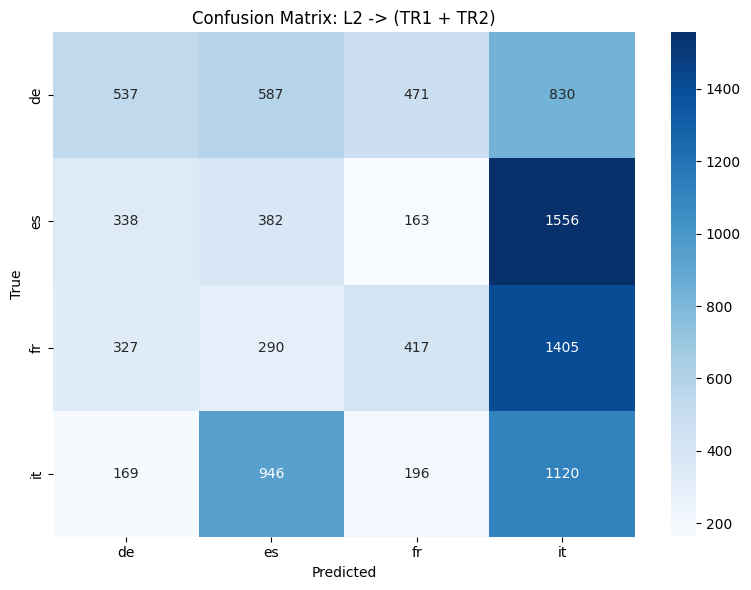

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.2523114855146908,
      de   es   fr    it
 de  537  587  471   830
 es  338  382  163  1556
 fr  327  290  417  1405
 it  169  946  196  1120)

In [21]:
train_one_test_two(
    L2,
    df_TR1_TR2,
    features,
    title="L2 -> (TR1 + TR2)"
)


===== TR2 -> (TR1 + L2) =====
Test Accuracy: 0.25379426644182124

Classification Report:
               precision    recall  f1-score   support

           0     0.3751    0.3010    0.3340      3253
           1     0.1982    0.1928    0.1955      3267
           2     0.2864    0.1619    0.2069      3267
           3     0.2168    0.3599    0.2706      3259

    accuracy                         0.2538     13046
   macro avg     0.2691    0.2539    0.2517     13046
weighted avg     0.2690    0.2538    0.2516     13046


Confusion Matrix:
      de    es   fr    it
de  979   994  415   865
es  429   630  474  1734
fr  710   390  529  1638
it  492  1165  429  1173


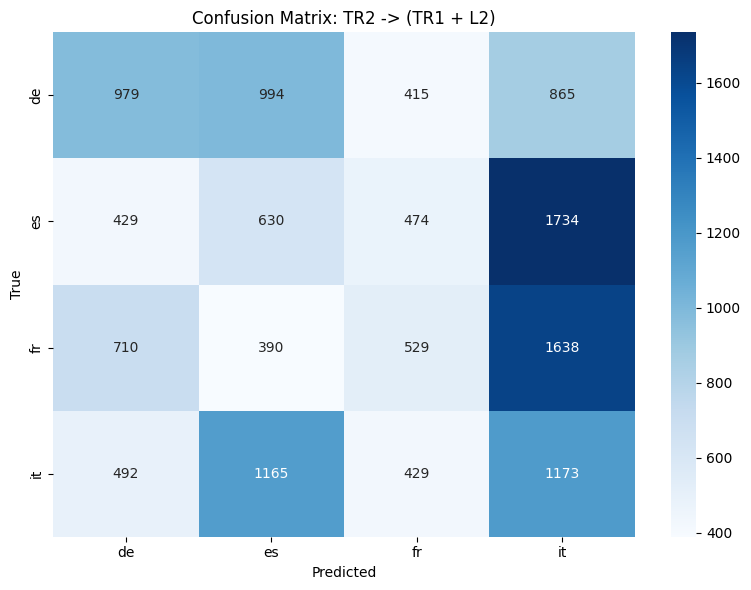

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25379426644182124,
      de    es   fr    it
 de  979   994  415   865
 es  429   630  474  1734
 fr  710   390  529  1638
 it  492  1165  429  1173)

In [22]:
train_one_test_two(
    TR2,
    df_TR1_L2,
    features,
    title="TR2 -> (TR1 + L2)"
)

### Downsampling everything to 272

In [23]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

df_L2_TR2 = pd.concat([L2, TR2], axis=0).reset_index(drop=True)
df_TR1_TR2 = pd.concat([TR1, TR2], axis=0).reset_index(drop=True)
df_TR1_L2 = pd.concat([TR1, L2], axis=0).reset_index(drop=True)

In [24]:
TR1 = TR1.dropna()
L2 = L2.dropna()
TR2 = TR2.dropna()


===== TR1 -> (L2 + TR2) =====
Test Accuracy: 0.25

Classification Report:
               precision    recall  f1-score   support

           0     0.3548    0.0404    0.0726       544
           1     0.2434    0.6783    0.3583       544
           2     0.4000    0.0368    0.0673       544
           3     0.2427    0.2445    0.2436       544

    accuracy                         0.2500      2176
   macro avg     0.3102    0.2500    0.1854      2176
weighted avg     0.3102    0.2500    0.1854      2176


Confusion Matrix:
     de   es  fr   it
de  22  386   6  130
es  13  369  10  152
fr  18  373  20  133
it   9  388  14  133


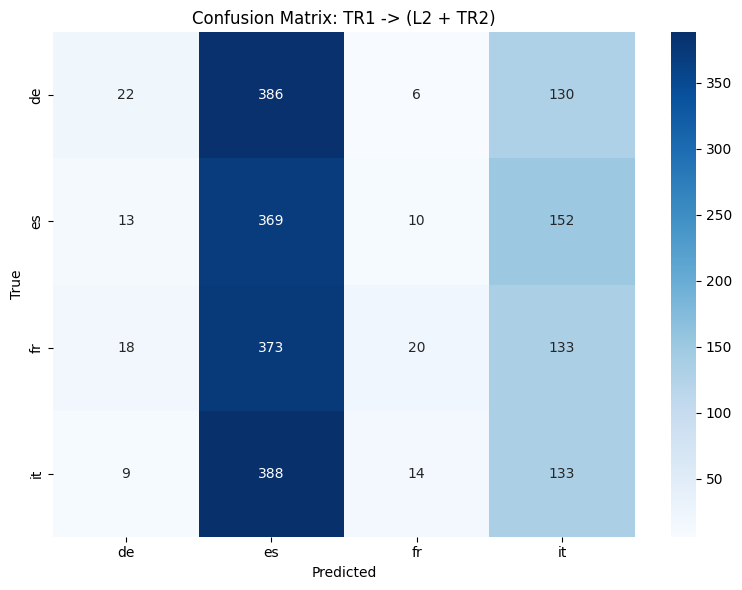

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25,
     de   es  fr   it
 de  22  386   6  130
 es  13  369  10  152
 fr  18  373  20  133
 it   9  388  14  133)

In [25]:
train_one_test_two(
    TR1,
    df_L2_TR2,
    features,
    title="TR1 -> (L2 + TR2)"
)


===== L2 -> (TR1 + TR2) =====
Test Accuracy: 0.25965073529411764

Classification Report:
               precision    recall  f1-score   support

           0     0.2753    0.1250    0.1719       544
           1     0.0874    0.0294    0.0440       544
           2     0.2699    0.3180    0.2920       544
           3     0.2787    0.5662    0.3736       544

    accuracy                         0.2597      2176
   macro avg     0.2278    0.2597    0.2204      2176
weighted avg     0.2278    0.2597    0.2204      2176


Confusion Matrix:
     de  es   fr   it
de  68  62  212  202
es  74  16  137  317
fr  84   9  173  278
it  21  96  119  308


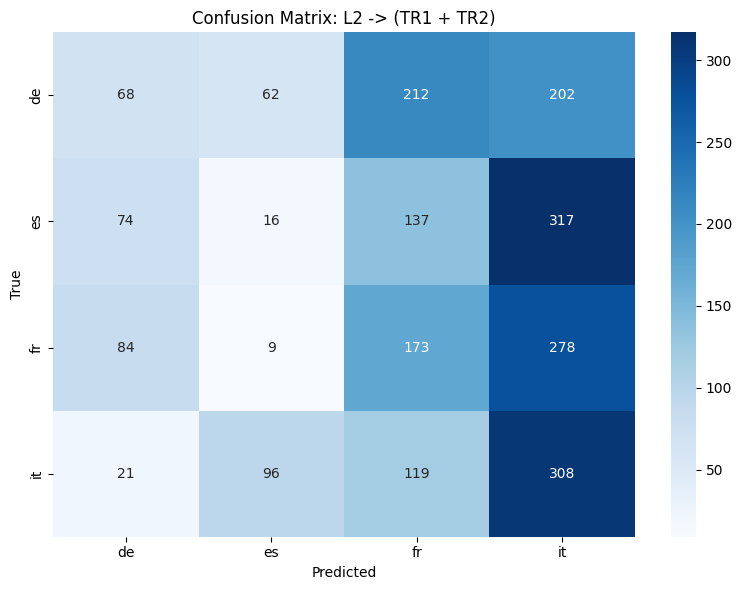

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.25965073529411764,
     de  es   fr   it
 de  68  62  212  202
 es  74  16  137  317
 fr  84   9  173  278
 it  21  96  119  308)

In [26]:
train_one_test_two(
    L2,
    df_TR1_TR2,
    features,
    title="L2 -> (TR1 + TR2)"
)


===== TR2 -> (TR1 + L2) =====
Test Accuracy: 0.27389705882352944

Classification Report:
               precision    recall  f1-score   support

           0     0.3750    0.3529    0.3636       544
           1     0.2281    0.2151    0.2214       544
           2     0.2704    0.1342    0.1794       544
           3     0.2429    0.3934    0.3004       544

    accuracy                         0.2739      2176
   macro avg     0.2791    0.2739    0.2662      2176
weighted avg     0.2791    0.2739    0.2662      2176


Confusion Matrix:
      de   es  fr   it
de  192  148  72  132
es   77  117  69  281
fr  149   68  73  254
it   94  180  56  214


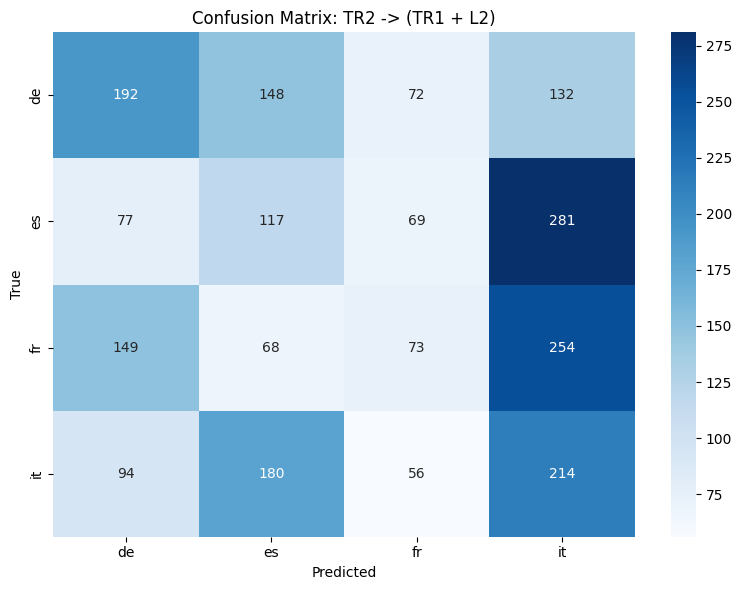

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.27389705882352944,
      de   es  fr   it
 de  192  148  72  132
 es   77  117  69  281
 fr  149   68  73  254
 it   94  180  56  214)

In [27]:
train_one_test_two(
    TR2,
    df_TR1_L2,
    features,
    title="TR2 -> (TR1 + L2)"
)

### Additionally: tested with TR2 with L2 and L1 individually as well


===== TR2 -> (L2) =====
Test Accuracy: 0.32628676470588236

Classification Report:
               precision    recall  f1-score   support

           0     0.3609    0.5772    0.4441       272
           1     0.2778    0.2022    0.2340       272
           2     0.3051    0.0662    0.1088       272
           3     0.3157    0.4596    0.3743       272

    accuracy                         0.3263      1088
   macro avg     0.3149    0.3263    0.2903      1088
weighted avg     0.3149    0.3263    0.2903      1088


Confusion Matrix:
      de  es  fr   it
de  157  41  13   61
es   68  55  18  131
fr  135  40  18   79
it   75  62  10  125


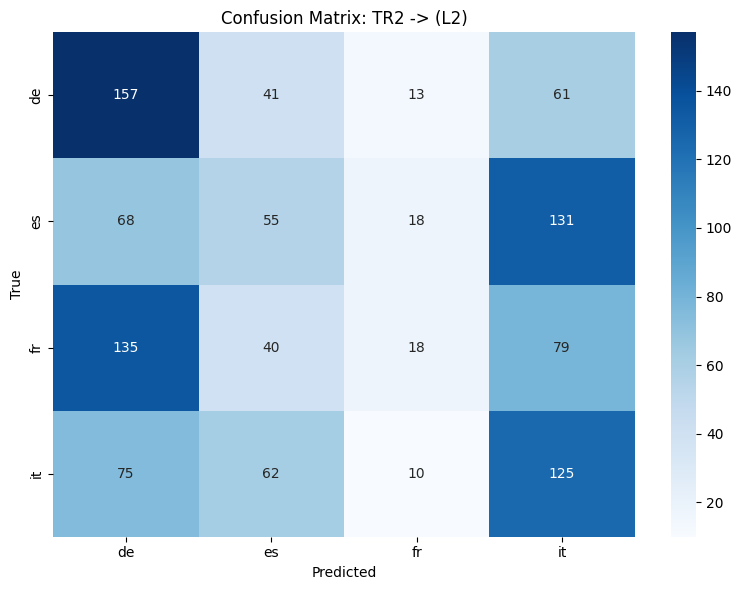

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.32628676470588236,
      de  es  fr   it
 de  157  41  13   61
 es   68  55  18  131
 fr  135  40  18   79
 it   75  62  10  125)

In [28]:
train_one_test_two(
    TR2,
    L2,
    features,
    title="TR2 -> (L2)"
)


===== TR2 -> (TR1) =====
Test Accuracy: 0.22150735294117646

Classification Report:
               precision    recall  f1-score   support

           0     0.4545    0.1287    0.2006       272
           1     0.1968    0.2279    0.2112       272
           2     0.2607    0.2022    0.2277       272
           3     0.1835    0.3272    0.2351       272

    accuracy                         0.2215      1088
   macro avg     0.2739    0.2215    0.2187      1088
weighted avg     0.2739    0.2215    0.2187      1088


Confusion Matrix:
     de   es  fr   it
de  35  107  59   71
es   9   62  51  150
fr  14   28  55  175
it  19  118  46   89


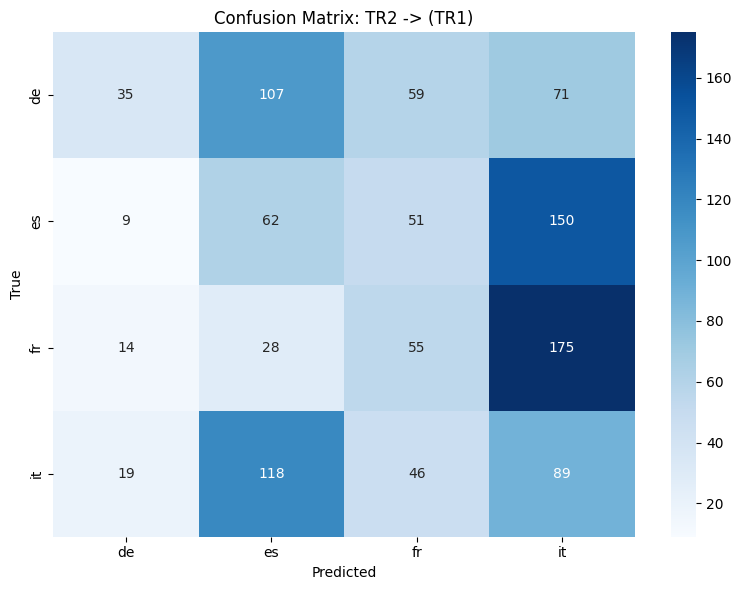

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.22150735294117646,
     de   es  fr   it
 de  35  107  59   71
 es   9   62  51  150
 fr  14   28  55  175
 it  19  118  46   89)

In [29]:
train_one_test_two(
    TR2,
    TR1,
    features,
    title="TR2 -> (TR1)"
)

# RQ2: Downsampling Every data to smallest available size (ES = 272 in europarl(TR2))

In [30]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

### Kmeans

Clustering Accuracy: 0.32536764705882354
Pred   de  es   fr  it
True                  
de    149   0  108  15
es     88   1  109  74
fr    127   0  124  21
it     80   0  112  80

Classification Report:
               precision    recall  f1-score   support

          de     0.3356    0.5478    0.4162       272
          es     1.0000    0.0037    0.0073       272
          fr     0.2737    0.4559    0.3421       272
          it     0.4211    0.2941    0.3463       272

    accuracy                         0.3254      1088
   macro avg     0.5076    0.3254    0.2780      1088
weighted avg     0.5076    0.3254    0.2780      1088



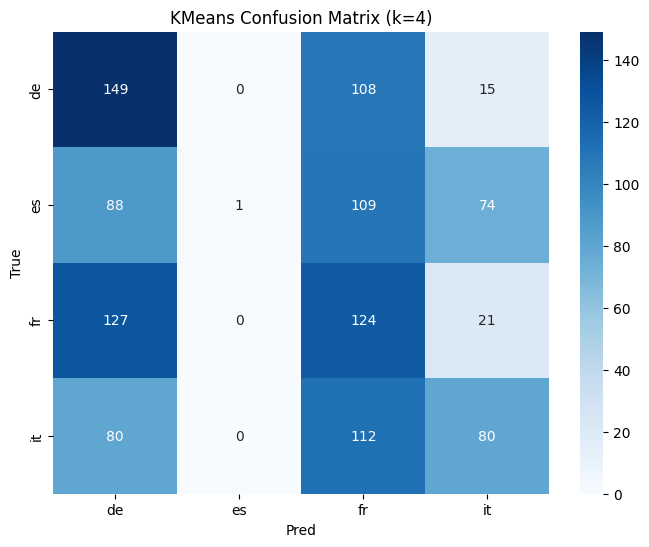

In [31]:
L2_df, acc, cm = run_kmeans_evaluation(L2, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"], plot=True)

Clustering Accuracy: 0.3648897058823529
Pred   de  es   fr  it
True                  
de    114  30   75  53
es    107  86   79   0
fr    109  45  118   0
it     34  75   84  79

Classification Report:
               precision    recall  f1-score   support

          de     0.3132    0.4191    0.3585       272
          es     0.3644    0.3162    0.3386       272
          fr     0.3315    0.4338    0.3758       272
          it     0.5985    0.2904    0.3911       272

    accuracy                         0.3649      1088
   macro avg     0.4019    0.3649    0.3660      1088
weighted avg     0.4019    0.3649    0.3660      1088



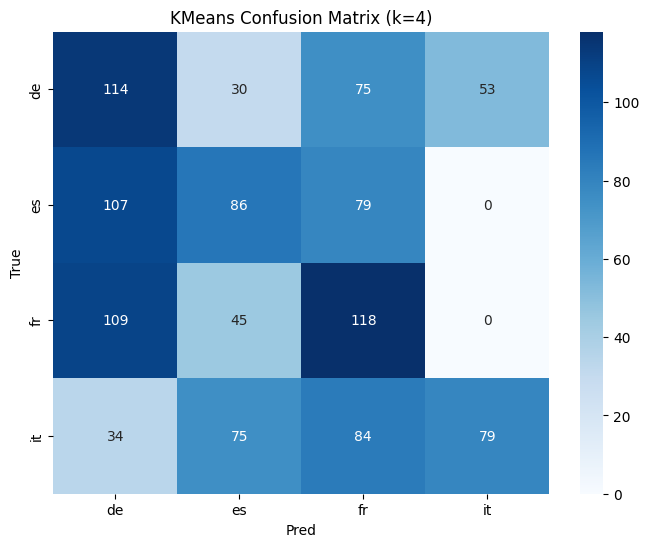

In [32]:
TR1_df, acc, cm = run_kmeans_evaluation(TR1, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"], plot=True)

Clustering Accuracy: 0.5211397058823529
Pred   de  es   fr   it
True                   
de    179  70   18    5
es     49  98   66   59
fr     74  34  155    9
it     13  67   57  135

Classification Report:
               precision    recall  f1-score   support

          de     0.5683    0.6581    0.6099       272
          es     0.3643    0.3603    0.3623       272
          fr     0.5236    0.5699    0.5458       272
          it     0.6490    0.4963    0.5625       272

    accuracy                         0.5211      1088
   macro avg     0.5263    0.5211    0.5201      1088
weighted avg     0.5263    0.5211    0.5201      1088



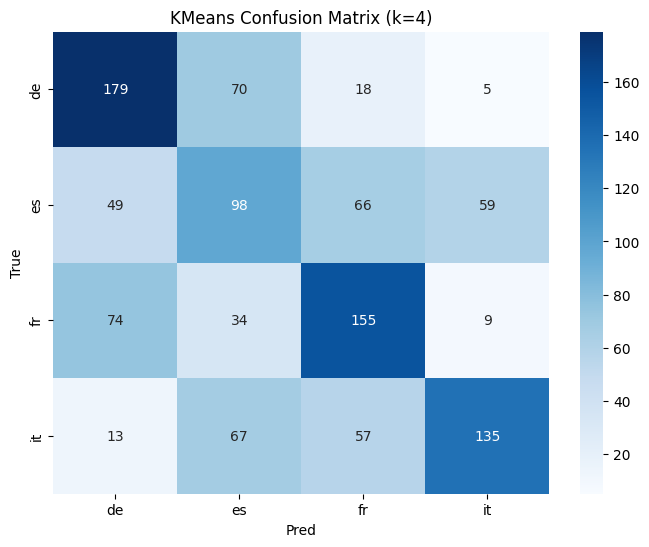

In [33]:
TR2_df, acc, cm = run_kmeans_evaluation(TR2, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num'], plot=True)

###NN


===== MLP Classification of L2 dataset(Test set) =====
Test Accuracy: 0.3302752293577982

Classification Report:
               precision    recall  f1-score   support

          de     0.3934    0.4364    0.4138        55
          es     0.2653    0.2407    0.2524        54
          fr     0.3226    0.3636    0.3419        55
          it     0.3261    0.2778    0.3000        54

    accuracy                         0.3303       218
   macro avg     0.3269    0.3296    0.3270       218
weighted avg     0.3271    0.3303    0.3275       218


Confusion matrix:
[[24 16 13  2]
 [12 13 13 16]
 [16  6 20 13]
 [ 9 14 16 15]]


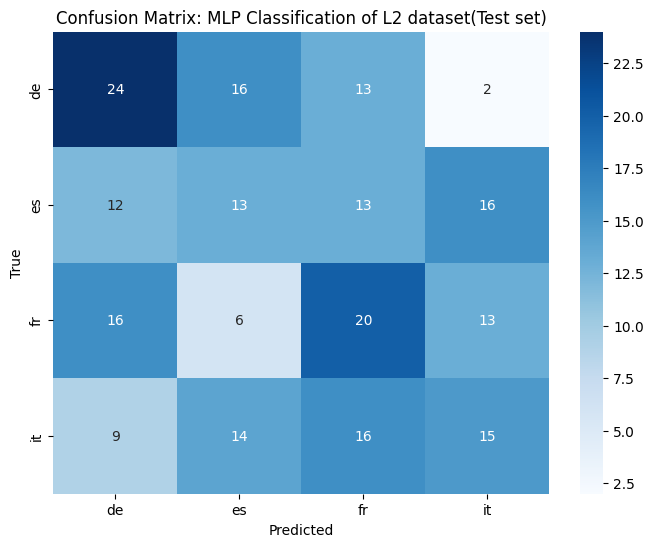

In [34]:
features = L2.drop(columns=['L1','L1_num',"dataset_name_map","dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(L2, features, label_col="L1", title="MLP Classification of L2 dataset(Test set)")


===== MLP Classification of TR1 dataset(Test set) =====
Test Accuracy: 0.5137614678899083

Classification Report:
               precision    recall  f1-score   support

          de     0.5094    0.4909    0.5000        55
          es     0.5217    0.4444    0.4800        54
          fr     0.5246    0.5818    0.5517        55
          it     0.5000    0.5370    0.5179        54

    accuracy                         0.5138       218
   macro avg     0.5139    0.5136    0.5124       218
weighted avg     0.5140    0.5138    0.5125       218


Confusion matrix:
[[27  7  3 18]
 [ 8 24 15  7]
 [12  7 32  4]
 [ 6  8 11 29]]


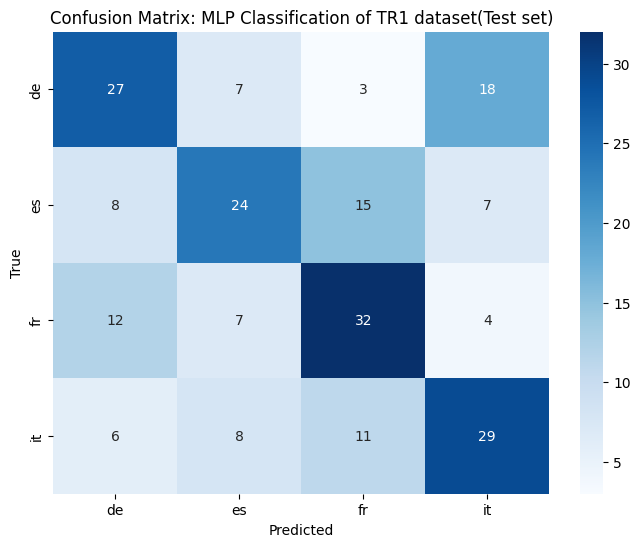

In [35]:
features = TR1.drop(columns=['L1','L1_num',"dataset_name_map","dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR1, features, label_col="L1", title="MLP Classification of TR1 dataset(Test set)")


===== MLP Classification of TR2 dataset(Test set) =====
Test Accuracy: 0.7706422018348624

Classification Report:
               precision    recall  f1-score   support

          de     0.8448    0.8909    0.8673        55
          es     0.6792    0.6667    0.6729        54
          fr     0.7593    0.7455    0.7523        55
          it     0.7925    0.7778    0.7850        54

    accuracy                         0.7706       218
   macro avg     0.7689    0.7702    0.7694       218
weighted avg     0.7692    0.7706    0.7697       218


Confusion matrix:
[[49  1  4  1]
 [ 4 36  6  8]
 [ 3  9 41  2]
 [ 2  7  3 42]]


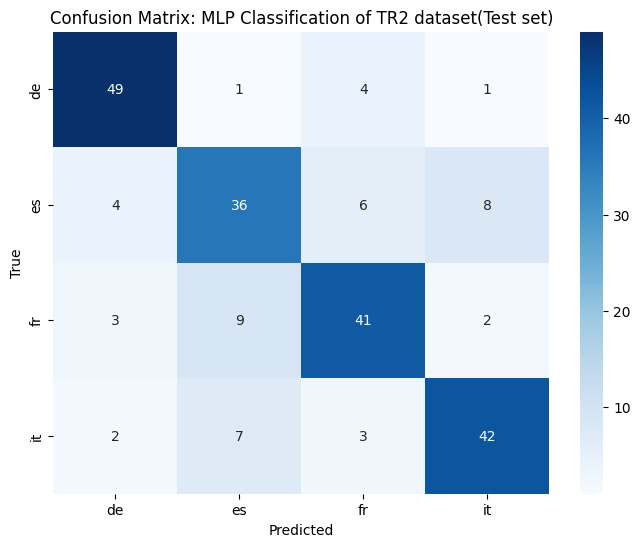

In [36]:
features = TR2.drop(columns=['L1','L1_num']).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR2, features, label_col="L1", title="MLP Classification of TR2 dataset(Test set)")

### Combining after downsampling

In [37]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)
df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Clustering Accuracy: 0.32169117647058826
Pred   de   es  fr   it
True                   
de    258  217   0   69
es    183  269   0   92
fr    247  266   0   31
it    198  173   0  173

Classification Report:
               precision    recall  f1-score   support

          de     0.2912    0.4743    0.3608       544
          es     0.2908    0.4945    0.3662       544
          fr     0.0000    0.0000    0.0000       544
          it     0.4740    0.3180    0.3806       544

    accuracy                         0.3217      2176
   macro avg     0.2640    0.3217    0.2769      2176
weighted avg     0.2640    0.3217    0.2769      2176



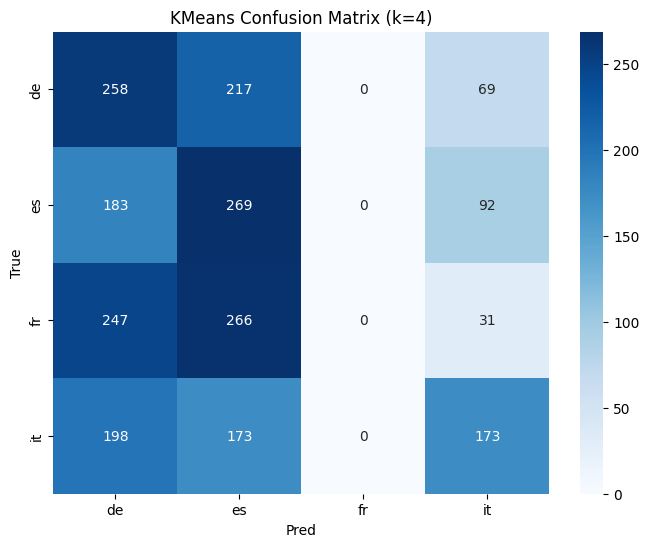

In [38]:
df, acc, cm = run_kmeans_evaluation(df, n_clusters=4, label_col='L1', drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"], plot=True)


===== MLP Classification of all dataset(Test set) =====
Test Accuracy: 0.4908256880733945

Classification Report:
               precision    recall  f1-score   support

          de     0.5385    0.3853    0.4492       109
          es     0.5135    0.5229    0.5182       109
          fr     0.4365    0.5046    0.4681       109
          it     0.4959    0.5505    0.5217       109

    accuracy                         0.4908       436
   macro avg     0.4961    0.4908    0.4893       436
weighted avg     0.4961    0.4908    0.4893       436


Confusion matrix:
[[42 11 30 26]
 [11 57 24 17]
 [15 21 55 18]
 [10 22 17 60]]


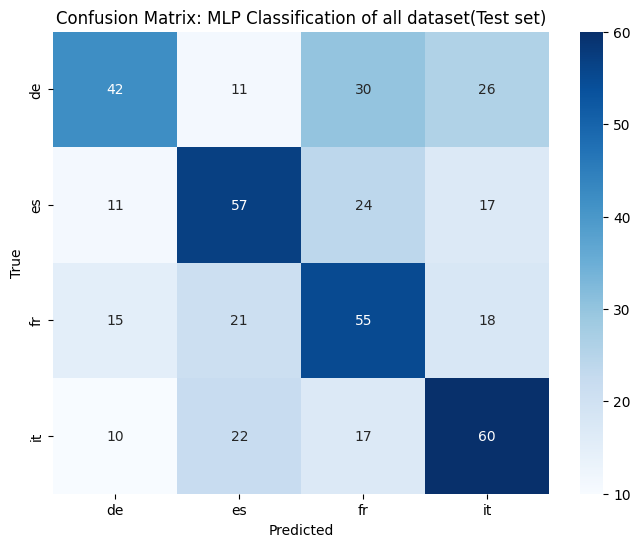

In [39]:
features = df.drop(columns=['L1','L1_num',"dataset_name_map","dataset_name"]).select_dtypes(include=[np.number]).columns
df = df.dropna()
mlp_model, acc, cm = run_nn(df, features, label_col="L1", title="MLP Classification of all dataset(Test set)")
#note: only test accuracy is here.

# RQ4: Do K-means with 3 clusters taking one language out each time

In [40]:
def leave_one_language_out_kmeans(df, label_col='L1', drop_cols=None, plot=False):

    results = {}
    languages = df[label_col].unique()

    for lang in languages:
        print("\n" + "="*50)
        print(f"Removing language: {lang}")
        print("="*50)

        # Filter out one language
        df_subset = df[df[label_col] != lang].copy()

        # Run KMeans on remaining languages
        _, acc, cm = run_kmeans_evaluation(
            df_subset,
            n_clusters=len(languages) - 1,
            label_col=label_col,
            drop_cols=drop_cols,
            plot=plot
        )

        # Store results
        results[lang] = {
            "accuracy": acc,
            "confusion_matrix": cm
        }

    return results



Removing language: de
Clustering Accuracy: 0.38909313725490197
Pred   es  fr   it
True              
es    271   0  273
fr    271   0  273
it    180   0  364

Classification Report:
               precision    recall  f1-score   support

          es     0.3753    0.4982    0.4281       544
          fr     0.0000    0.0000    0.0000       544
          it     0.4000    0.6691    0.5007       544

    accuracy                         0.3891      1632
   macro avg     0.2584    0.3891    0.3096      1632
weighted avg     0.2584    0.3891    0.3096      1632



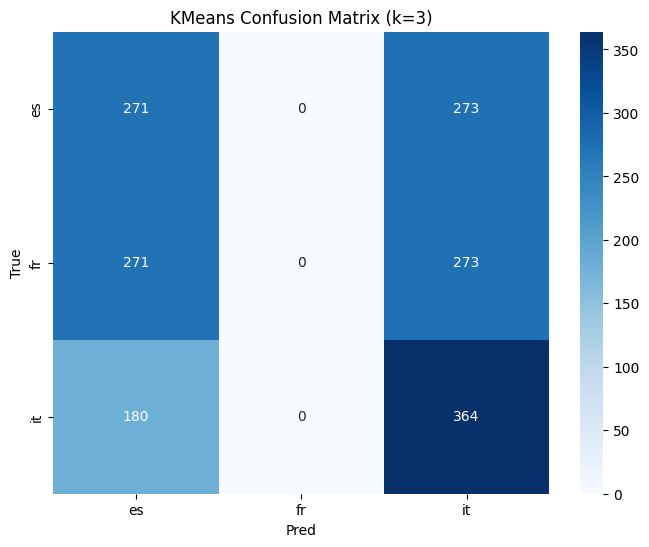


Removing language: es
Clustering Accuracy: 0.38786764705882354
Pred  de   fr   it
True              
de     0  220  324
fr     0  267  277
it     0  178  366

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       544
          fr     0.4015    0.4908    0.4417       544
          it     0.3785    0.6728    0.4844       544

    accuracy                         0.3879      1632
   macro avg     0.2600    0.3879    0.3087      1632
weighted avg     0.2600    0.3879    0.3087      1632



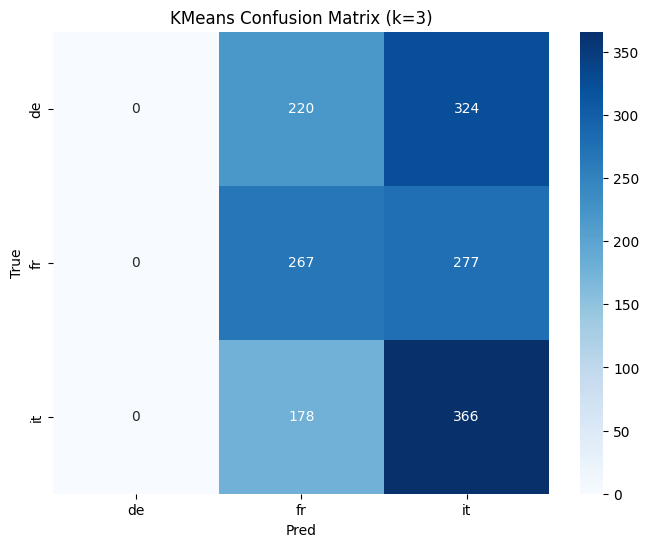


Removing language: fr
Clustering Accuracy: 0.38909313725490197
Pred  de   es   it
True              
de     0  220  324
es     0  271  273
it     0  180  364

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       544
          es     0.4039    0.4982    0.4461       544
          it     0.3788    0.6691    0.4837       544

    accuracy                         0.3891      1632
   macro avg     0.2609    0.3891    0.3099      1632
weighted avg     0.2609    0.3891    0.3099      1632



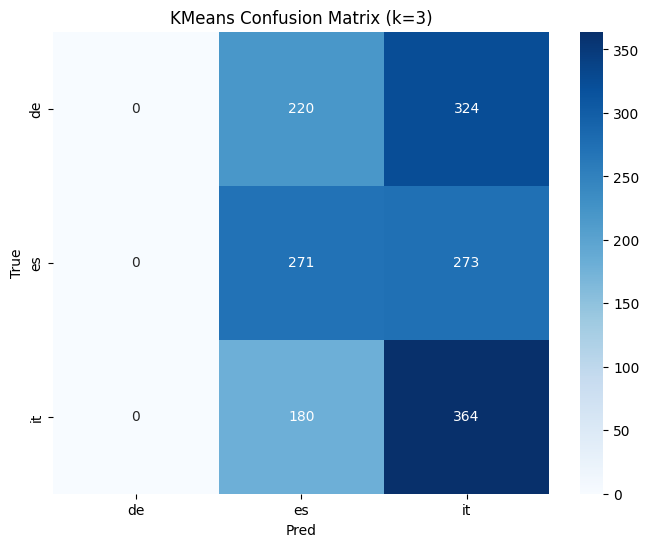


Removing language: it
Clustering Accuracy: 0.36580882352941174
Pred  de   es   fr
True              
de    52  219  273
es     0  270  274
fr     0  269  275

Classification Report:
               precision    recall  f1-score   support

          de     1.0000    0.0956    0.1745       544
          es     0.3562    0.4963    0.4147       544
          fr     0.3345    0.5055    0.4026       544

    accuracy                         0.3658      1632
   macro avg     0.5636    0.3658    0.3306      1632
weighted avg     0.5636    0.3658    0.3306      1632



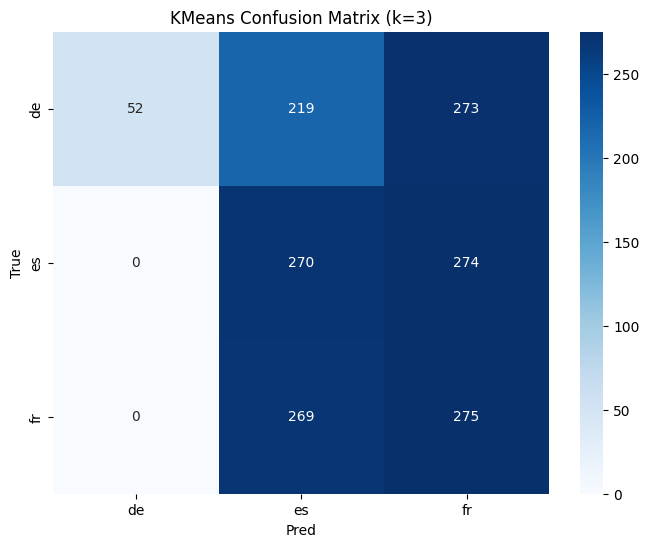

In [41]:

results = leave_one_language_out_kmeans(
df,
label_col='L1',
drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"],
plot=True   # or False if too many plots
)

## L2


Removing language: de
Clustering Accuracy: 0.42034313725490197
Pred   es   fr  it
True              
es    119  153   0
fr     48  224   0
it    112  160   0

Classification Report:
               precision    recall  f1-score   support

          es     0.4265    0.4375    0.4319       272
          fr     0.4171    0.8235    0.5538       272
          it     0.0000    0.0000    0.0000       272

    accuracy                         0.4203       816
   macro avg     0.2812    0.4203    0.3286       816
weighted avg     0.2812    0.4203    0.3286       816



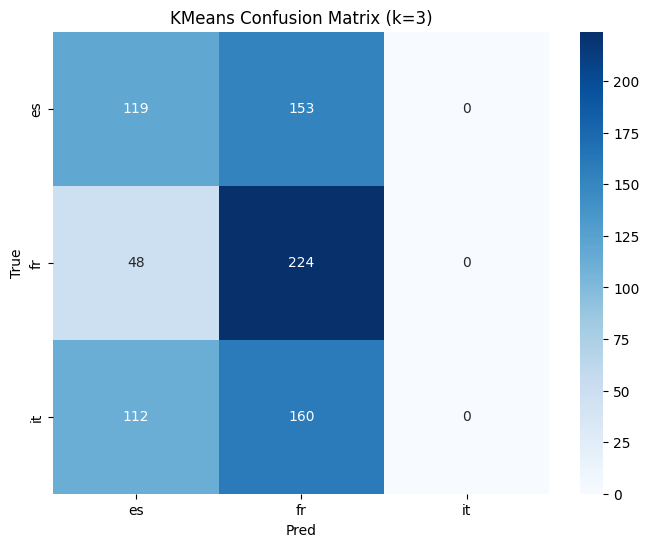


Removing language: es
Clustering Accuracy: 0.4424019607843137
Pred   de   fr   it
True               
de    132  115   25
fr    106  127   39
it     70  100  102

Classification Report:
               precision    recall  f1-score   support

          de     0.4286    0.4853    0.4552       272
          fr     0.3713    0.4669    0.4137       272
          it     0.6145    0.3750    0.4658       272

    accuracy                         0.4424       816
   macro avg     0.4715    0.4424    0.4449       816
weighted avg     0.4715    0.4424    0.4449       816



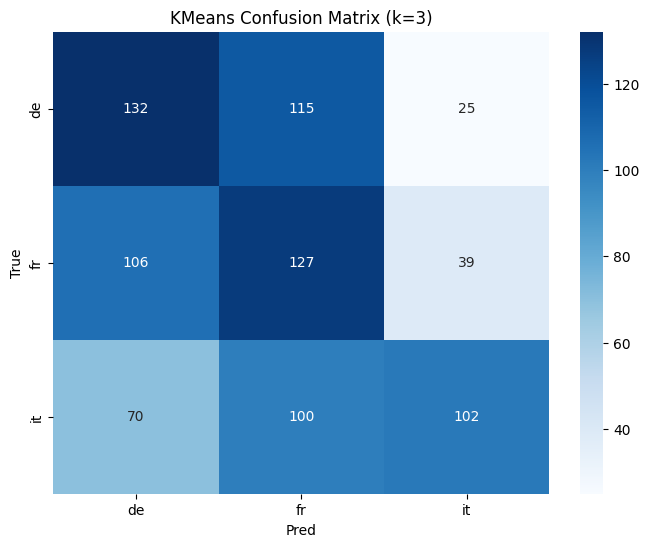


Removing language: fr
Clustering Accuracy: 0.39705882352941174
Pred   de  es  it
True             
de    268   4   0
es    216  56   0
it    227  45   0

Classification Report:
               precision    recall  f1-score   support

          de     0.3769    0.9853    0.5453       272
          es     0.5333    0.2059    0.2971       272
          it     0.0000    0.0000    0.0000       272

    accuracy                         0.3971       816
   macro avg     0.3034    0.3971    0.2808       816
weighted avg     0.3034    0.3971    0.2808       816



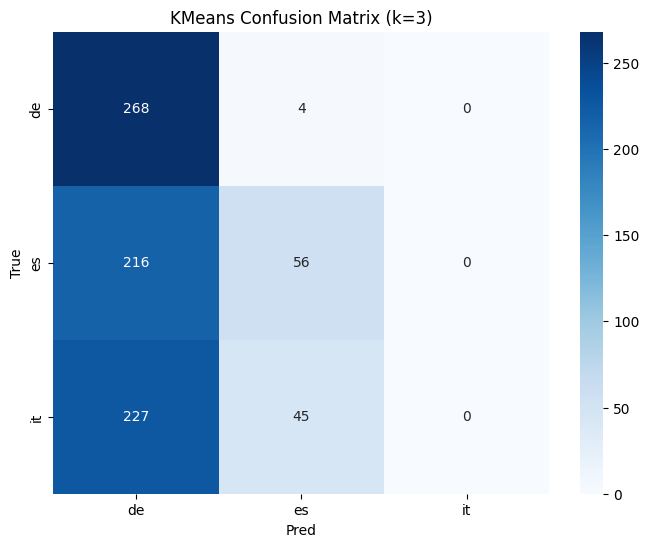


Removing language: it
Clustering Accuracy: 0.43137254901960786
Pred   de   es  fr
True              
de    195   77   0
es    115  157   0
fr    181   91   0

Classification Report:
               precision    recall  f1-score   support

          de     0.3971    0.7169    0.5111       272
          es     0.4831    0.5772    0.5260       272
          fr     0.0000    0.0000    0.0000       272

    accuracy                         0.4314       816
   macro avg     0.2934    0.4314    0.3457       816
weighted avg     0.2934    0.4314    0.3457       816



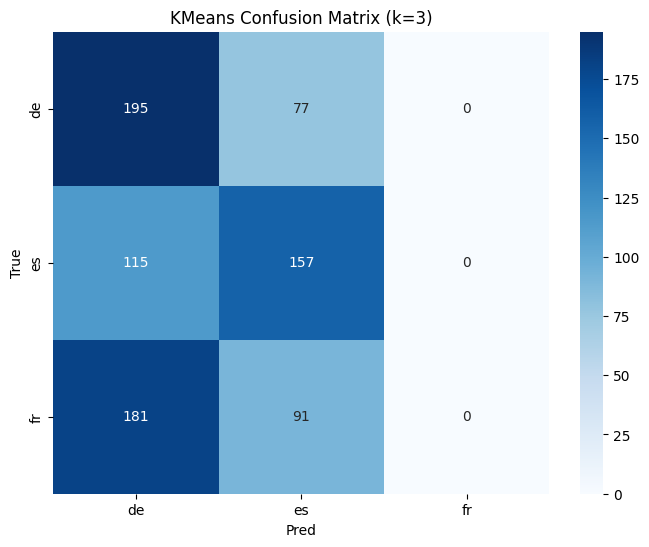

In [45]:

results = leave_one_language_out_kmeans(
L2,
label_col='L1',
drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"],
plot=True   # or False if too many plots
)

## TR1


Removing language: de
Clustering Accuracy: 0.49387254901960786
Pred   es   fr  it
True              
es    111  161   0
fr     59  213   0
it     87  106  79

Classification Report:
               precision    recall  f1-score   support

          es     0.4319    0.4081    0.4197       272
          fr     0.4437    0.7831    0.5665       272
          it     1.0000    0.2904    0.4501       272

    accuracy                         0.4939       816
   macro avg     0.6252    0.4939    0.4788       816
weighted avg     0.6252    0.4939    0.4788       816



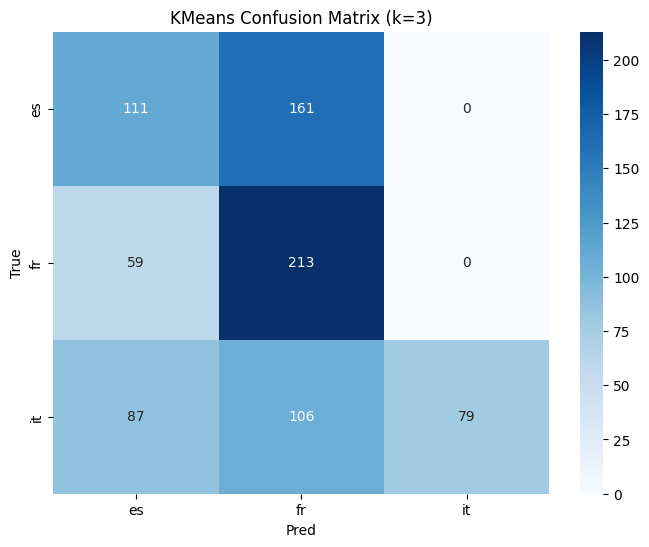


Removing language: es
Clustering Accuracy: 0.4534313725490196
Pred  de   fr   it
True              
de     0  172  100
fr     0  194   78
it     0   96  176

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       272
          fr     0.4199    0.7132    0.5286       272
          it     0.4972    0.6471    0.5623       272

    accuracy                         0.4534       816
   macro avg     0.3057    0.4534    0.3636       816
weighted avg     0.3057    0.4534    0.3636       816



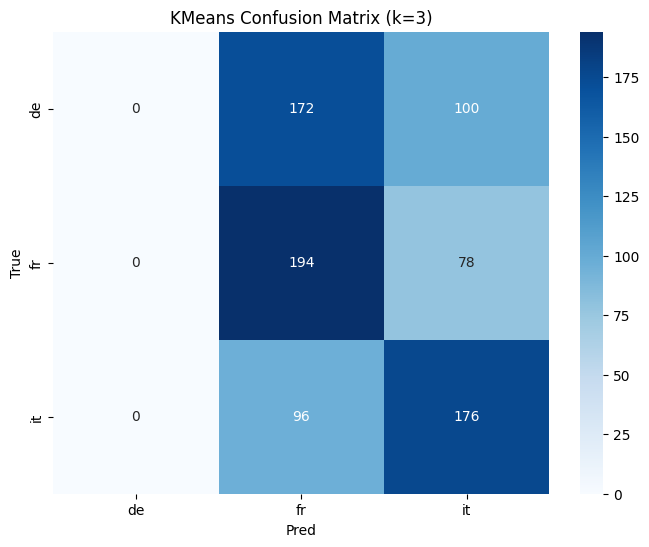


Removing language: fr
Clustering Accuracy: 0.47058823529411764
Pred   de   es  it
True              
de    173   46  53
es    140  132   0
it    100   93  79

Classification Report:
               precision    recall  f1-score   support

          de     0.4189    0.6360    0.5051       272
          es     0.4871    0.4853    0.4862       272
          it     0.5985    0.2904    0.3911       272

    accuracy                         0.4706       816
   macro avg     0.5015    0.4706    0.4608       816
weighted avg     0.5015    0.4706    0.4608       816



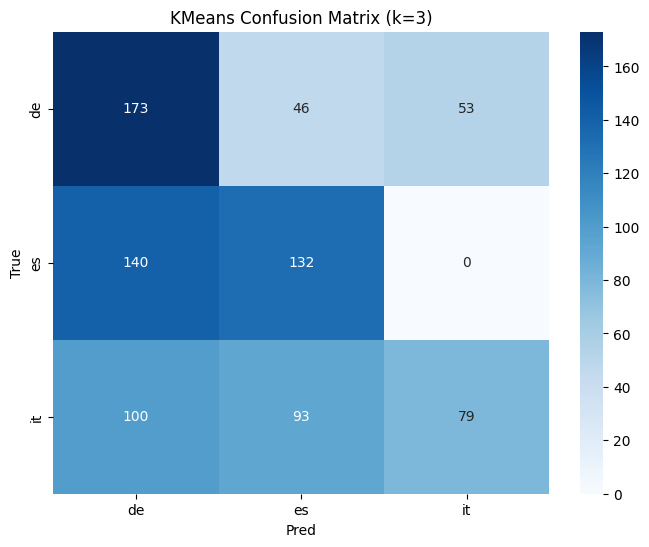


Removing language: it
Clustering Accuracy: 0.45465686274509803
Pred   de   es  fr
True              
de    210   62   0
es    111  161   0
fr    140  132   0

Classification Report:
               precision    recall  f1-score   support

          de     0.4555    0.7721    0.5730       272
          es     0.4535    0.5919    0.5136       272
          fr     0.0000    0.0000    0.0000       272

    accuracy                         0.4547       816
   macro avg     0.3030    0.4547    0.3622       816
weighted avg     0.3030    0.4547    0.3622       816



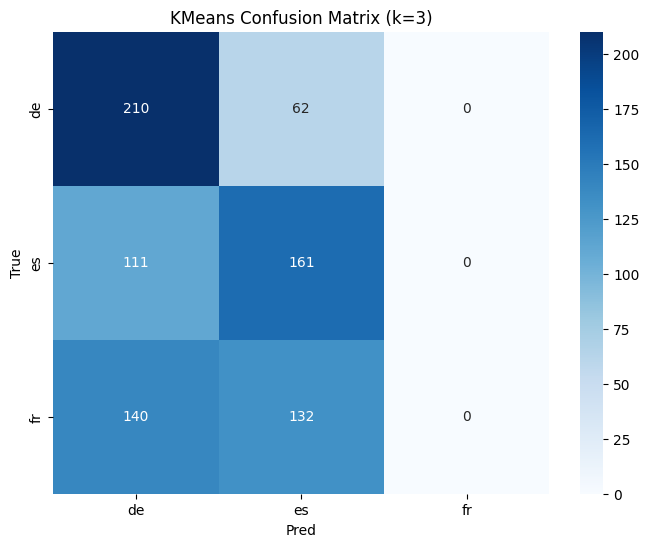

In [46]:

results = leave_one_language_out_kmeans(
TR1,
label_col='L1',
drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"],
plot=True   # or False if too many plots
)

## TR2


Removing language: de
Clustering Accuracy: 0.5919117647058824
Pred  es   fr   it
True              
es    78  103   91
fr    26  226   20
it    38   55  179

Classification Report:
               precision    recall  f1-score   support

          es     0.5493    0.2868    0.3768       272
          fr     0.5885    0.8309    0.6890       272
          it     0.6172    0.6581    0.6370       272

    accuracy                         0.5919       816
   macro avg     0.5850    0.5919    0.5676       816
weighted avg     0.5850    0.5919    0.5676       816



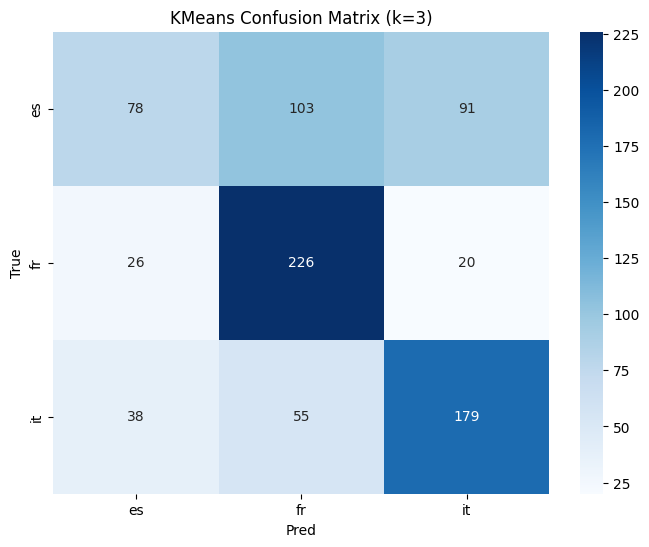


Removing language: es
Clustering Accuracy: 0.6862745098039216
Pred   de   fr   it
True               
de    218   46    8
fr     84  176   12
it     33   73  166

Classification Report:
               precision    recall  f1-score   support

          de     0.6507    0.8015    0.7183       272
          fr     0.5966    0.6471    0.6208       272
          it     0.8925    0.6103    0.7249       272

    accuracy                         0.6863       816
   macro avg     0.7133    0.6863    0.6880       816
weighted avg     0.7133    0.6863    0.6880       816



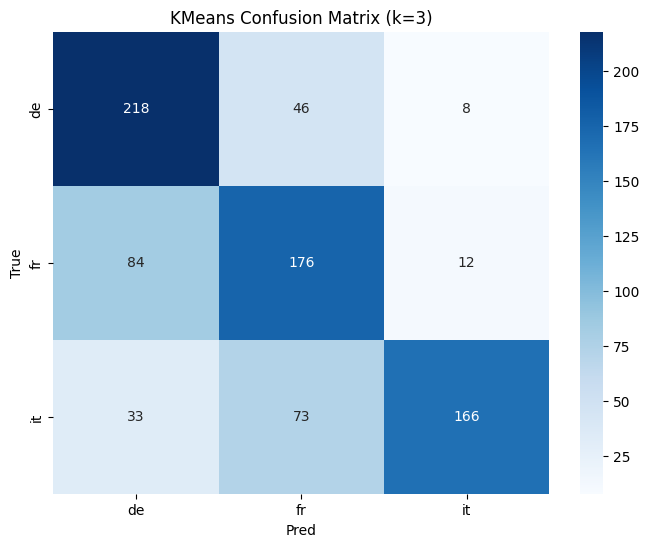


Removing language: fr
Clustering Accuracy: 0.5747549019607843
Pred   de   es   it
True               
de    192   75    5
es     81  116   75
it     31   80  161

Classification Report:
               precision    recall  f1-score   support

          de     0.6316    0.7059    0.6667       272
          es     0.4280    0.4265    0.4273       272
          it     0.6680    0.5919    0.6277       272

    accuracy                         0.5748       816
   macro avg     0.5759    0.5748    0.5739       816
weighted avg     0.5759    0.5748    0.5739       816



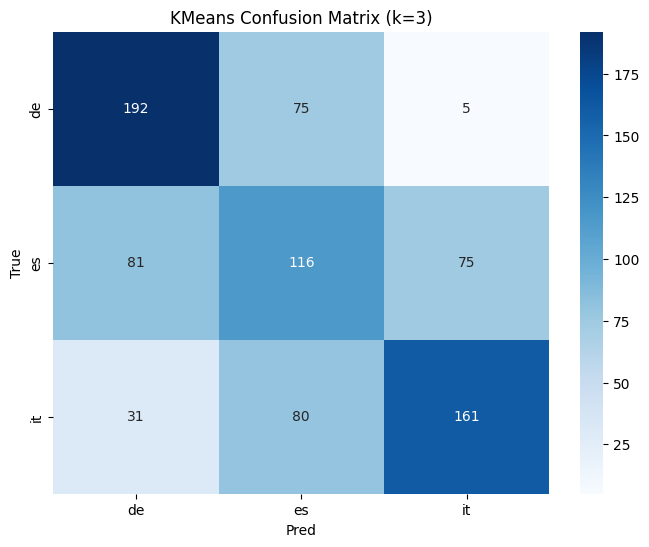


Removing language: it
Clustering Accuracy: 0.6115196078431373
Pred   de   es   fr
True               
de    204   14   54
es     69  122   81
fr     78   21  173

Classification Report:
               precision    recall  f1-score   support

          de     0.5812    0.7500    0.6549       272
          es     0.7771    0.4485    0.5688       272
          fr     0.5617    0.6360    0.5966       272

    accuracy                         0.6115       816
   macro avg     0.6400    0.6115    0.6067       816
weighted avg     0.6400    0.6115    0.6067       816



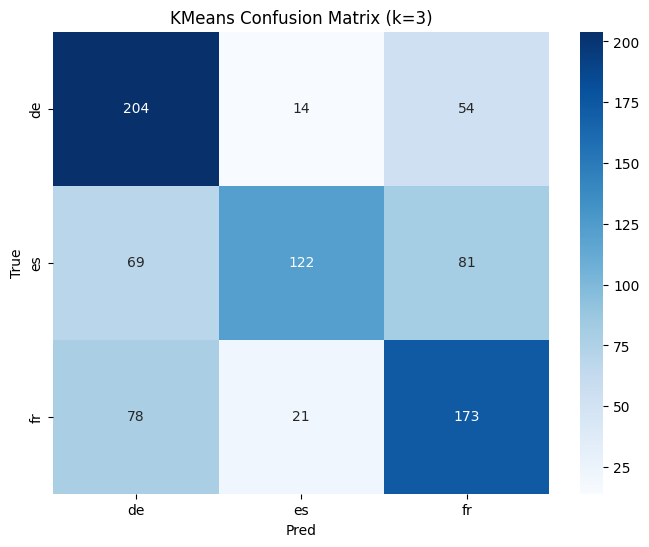

In [48]:

results = leave_one_language_out_kmeans(
TR2,
label_col='L1',
drop_cols=['L1','L1_num'],
plot=True   # or False if too many plots
)

### Issue: always tries to make 2 clusters instead of 3.

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

def plot_pca(df, label_col='L1', drop_cols=None):

    df = df.dropna().copy()

    # Labels
    y = df[label_col].values

    # Features
    if drop_cols is not None:
        X = df.drop(drop_cols, axis=1).values
    else:
        X = df.drop(columns=[label_col]).values

    # Scale (VERY important for PCA)
    X = StandardScaler().fit_transform(X)

    # Apply PCA → 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Language': y
    })

    # Plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='Language', alpha=0.7)
    plt.title('PCA Projection of Languages')
    plt.legend()
    plt.show()

    # Explained variance (important!)
    print("Explained variance ratio:", pca.explained_variance_ratio_)

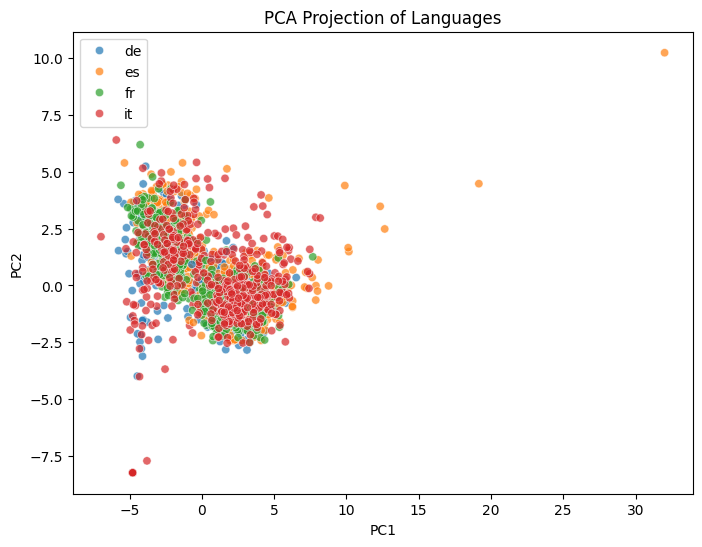

Explained variance ratio: [0.23763123 0.1629002 ]


In [50]:
plot_pca(
    df,
    label_col='L1',
    drop_cols=['L1','L1_num',"dataset_name_map","dataset_name"]
)